In [1]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm

# Paths
DATASET_ROOT = "../datasets/laticifers"
labeled_dir = os.path.join(DATASET_ROOT, "labeled_images")
mask_dir = os.path.join(DATASET_ROOT, "masks")

os.makedirs(mask_dir, exist_ok=True)

# Red detection thresholds
RED_THRESHOLD = 100     # Red must be > this
GREEN_MAX = 80          # Green must be < this
BLUE_MAX = 80           # Blue must be < this

# File extensions to process
VALID_EXTS = (".tif", ".png", ".jpg", ".jpeg")

# Process all labeled images
for fname in tqdm(sorted(os.listdir(labeled_dir))):
    if not fname.lower().endswith(VALID_EXTS):
        continue

    # Load image
    img_path = os.path.join(labeled_dir, fname)
    img = Image.open(img_path).convert("RGB")
    img_np = np.array(img)

    # Extract RGB channels
    red, green, blue = img_np[:, :, 0], img_np[:, :, 1], img_np[:, :, 2]

    # Create binary mask where red is dominant
    mask = (red > RED_THRESHOLD) & (green < GREEN_MAX) & (blue < BLUE_MAX)
    mask = mask.astype(np.uint8) * 255  # Convert to 0-255 image

    # Save mask
    mask_img = Image.fromarray(mask)
    name, ext = os.path.splitext(fname)
    if " marcada" in name:
        name = name.replace(" marcada", "")
    mask_filename = f"{name}{ext}"
    mask_img.save(os.path.join(mask_dir, mask_filename))

print(f"✅ Extracted masks saved to: {mask_dir}")

100%|██████████| 35/35 [00:02<00:00, 12.18it/s]

✅ Extracted masks saved to: ../datasets/laticifers/masks


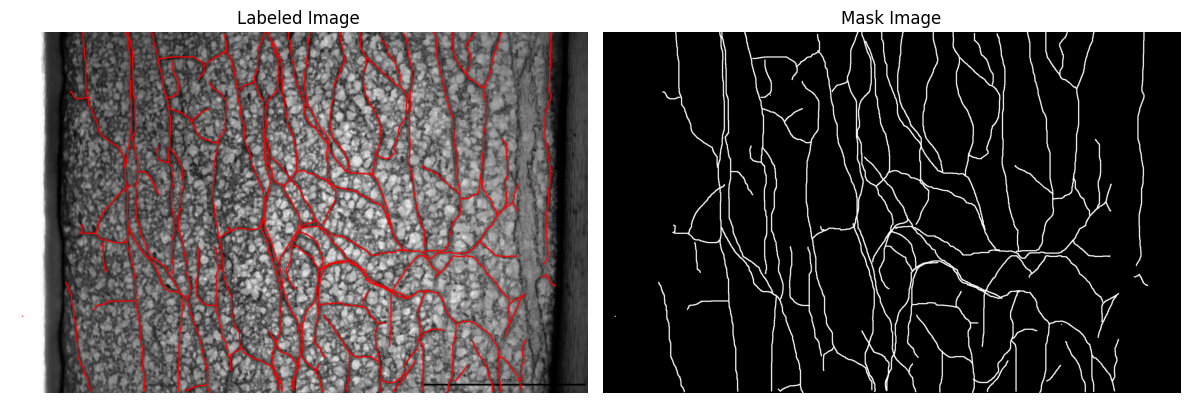

In [4]:
import matplotlib.pyplot as plt

mask_path = os.listdir(mask_dir)[1]

mask_img = Image.open(os.path.join(mask_dir, mask_path))
labeled_img = Image.open(os.path.join(labeled_dir, mask_path[:-4] + " marcada.tif"))

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(labeled_img)
axs[0].set_title("Labeled Image")
axs[0].axis('off')

axs[1].imshow(mask_img, cmap='gray')
axs[1].set_title("Mask Image")
axs[1].axis('off')

plt.tight_layout()
plt.show()